11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


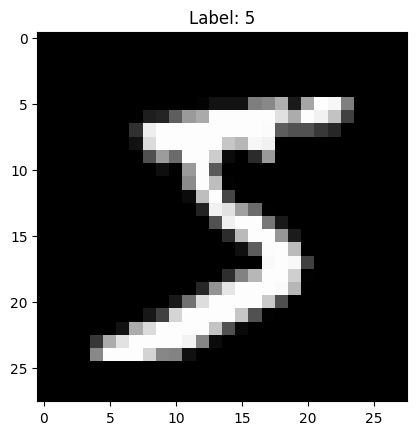

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9246 - loss: 0.2629 - val_accuracy: 0.9597 - val_loss: 0.1361
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9657 - loss: 0.1169 - val_accuracy: 0.9714 - val_loss: 0.0949
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9757 - loss: 0.0803 - val_accuracy: 0.9692 - val_loss: 0.1001
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9813 - loss: 0.0614 - val_accuracy: 0.9755 - val_loss: 0.0788
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9848 - loss: 0.0483 - val_accuracy: 0.9756 - val_loss: 0.0783
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9756 - loss: 0.0783
Accuracy: 0.975600004196167
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


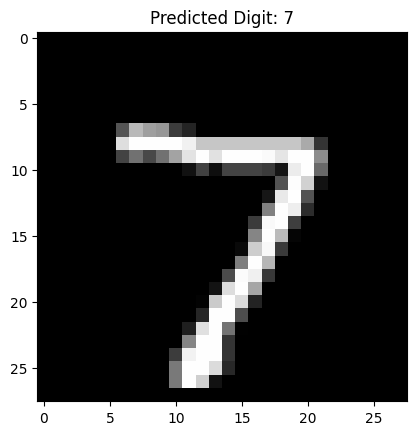

Model saved successfully!


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Show sample image
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

# Normalize data
X_train = X_train / 255.0
X_test = X_test / 255.0

# Build model
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

# Predictions
predictions = model.predict(X_test)

plt.imshow(X_test[0], cmap='gray')
plt.title(f"Predicted Digit: {np.argmax(predictions[0])}")
plt.show()

# Save model
model.save("digit_recognition_model.h5")

print("Model saved successfully!")